<a href="https://colab.research.google.com/github/vabigdatamover/Barhorst_DataBootCamp_HW/blob/master/Intro_AI_Lab6_rev1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to AI Lab6**

### The objective of this laboratory exercise is to implement the "Q-learning" algorithm. We will construct a confined Gridworld environment to facilitate agent training and performance evaluation.

# Active Reinforcement Learning (Q-learning)

<font size="4">__Q-learning__ is an important __model-free reinforcement learning__ technique. Its primary function is to determine the __expected quality (Q-value)__ of taking a specific action while in a specific state. Since it is "model-free," it does not need a full map of the environment, which allows it to naturally manage problems involving __stochastic (probabilistic) transitions and rewards__. This lab will be dedicated to exploring and implementing this algorithm.  </font>

### *Simple Gridworld problem Design*

<font size="4">We'll begin by building the __Gridworld environment__. This is a $3 \times 4$ grid defined by __boundaries__, a __wall block__, and specific locations that yield __positive__ or __negative terminal rewards__. The complete layout is shown in __Figure 1__. </font>
<div style="float: left; margin-right: 50px; margin-left: 100px;">
    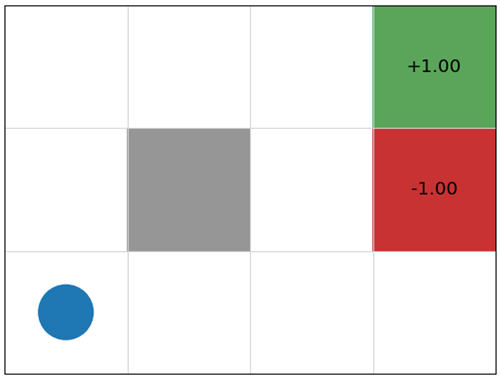
    <p>Figure 1. Small Gridworld</p>
</div>
<div style="float: left;">
    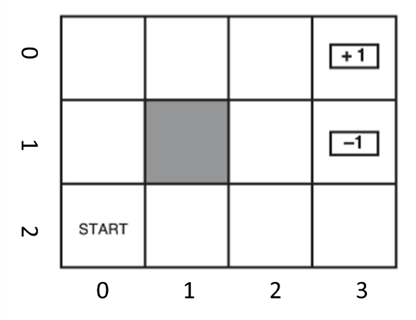
    <p>Figure 2. Coordinates of small gridworld</p>
</div>

<div style="clear: both;"></div>

<font size="4">__Figure 1__ displays the Gridworld environment. The __blue dot__ is the agent's __starting state__. The __green__ and __red__ cells are the __terminal states__, providing rewards of $+1$ and $-1$, respectively. Upon reaching either terminal state, the episode ends, and the agent automatically resets to the starting (blue) state for the next episode. The agent __cannot move outside the boundary__ or enter the __wall cell__ (in gray). __Figure 2__ shows the coordinates you will use for the Gridworld implementation.</font>

### Step 1
<font size="4"> First, we will set up the Gridword environment. <br>
The gridworld has 3 rows and 4 columns. So we will use cartesian coordinate for the state.<br><br>
(0,0) | (0,1) | (0,2) |  +1 <br>
(1,0) |  Wall | (1,2) |  -1 <br>
(2,0) | (2,1) | (2,2) | (2,3) <br></font>

<font size="4"> __Wall cell__ is in (1,1)<br>
__Positive reward__ (+1) is in (0,3)<br>
__Negative reward__ (-1) is in (1,3)<br></font>

<font size="4">In next code cell, assign the number of rows and columns. Then, RUN it. </font>

In [1]:
# Define the number of rows and columns for the Gridworld environment.
NUM_ROW = 3
NUM_COL = 4

### Step 2
<font size="4">We will define the agent's possible actions as __Up__, __Down__, __Left__, and __Right__.<br></font>
#### Action Design and Stochastic Movement
<font size="4">Designing these actions requires careful consideration due to the problem's inherent stochasticity (random movement). When the agent is instructed to perform an action, the outcome is probabilistic: <br>
__Intended Direction__: $80\%$ probability of moving in the commanded direction (e.g., instructing 'Up' results in movement 'Up').<br>
__Perpendicular Deviations__: $10\%$ probability of moving one unit to the right and $10\%$ probability of moving one unit to the left of the intended direction.  </font>
#### Implementation
<font size="4">The actions must be represented as coordinate differences ($\Delta x, \Delta y$) for implementation. The total number of actions must be specified. Complete the list of actions and the total count in the next code cell and execute it.</font>

In [2]:
# Set up the initial environment
NUM_ACTIONS = 4
ACTIONS = [(1, 0), (0, -1), (-1, 0), (0, 1)] # Down, Left, Up, Right

### Step 3
<font size="4">Our next step is to initialize the __Value Function__ $\mathbf{V(s)}$ and __Q table__ $\mathbf{Q(s,a)}$. The values assigned to each state are critical, as they will be iteratively updated by the MDP algorithm to ultimately derive the optimal policy (i.e., the best action in every state).<br>
#### Rewards
<font size="4">Keep in mind that the __terminal rewards__ are associated with the states at $(0, 3)$ and $(1, 3)$.</font> <br>
#### Task
<font size="4">Define and initialize the values for all states $\mathbf{V}$ in the next code cell, and then execute it.</font>

In [3]:
#Initialize U  for state values
U = [[0,0,0,1], [0,0,0,-1], [0,0,0,0]]

# Initialize Q values for only valid state in the order of Down, Left, Up, Right.
# Use dictionary: key is state in tuple and q values in the list.
Q = {(0,0): [0,0,0,0], (0,1): [0,0,0,0], (0,2): [0,0,0,0],
(1,0): [0,0,0,0], (1,2): [0,0,0,0],
(2,0): [0,0,0,0] , (2,1): [0,0,0,0], (2,2): [0,0,0,0], (2,3): [0,0,0,0]    }

<font size="4">The following code provides a simple visualization function. <br>
It takes the state values and the policy as inputs. The visualization mode is controlled by a boolean flag: True displays the policy, and False displays the state values. <br>
Run the next code cell. </font>

In [4]:
# Visualization
def printEnvironment(arr, policy=False):
    ACTION_LABELS = ["D", "L", "U", "R"]
    res = ""

    if policy:
        # Show ONLY the best (argmax) action for each state, one line per row
        for r in range(NUM_ROW):
            res += "|"
            for c in range(NUM_COL):
                if r == c == 1:
                    val = "WALL"
                elif r <= 1 and c == 3:
                    val = "+1" if r == 0 else "-1"
                else:
                    best = max(range(NUM_ACTIONS), key=lambda a: arr[(r, c)][a])
                    val = ACTION_LABELS[best]
                res += " " + val.center(6) + " |"
            res += "\n"
    else:
        # Show all 4 Q-values for each state (original detailed view)
        for r in range(NUM_ROW):
            for ats in range(NUM_ACTIONS):
                res += "|"
                for c in range(NUM_COL):
                    if r == c == 1:
                        val = "WALL" if ats == 1 else " "
                    elif r <= 1 and c == 3:
                        val = ("+1" if r == 0 else "-1") if ats == 1 else " "
                    else:
                        val = ACTION_LABELS[ats] + ": " + str(round(arr[(r, c)][ats], 3))
                    res += " " + val[:12].ljust(12) + " |"
                res += "\n"
            res += "\n"

    print(res)


### Step 5: Action Selection
<font size="4">We will implement the __$\epsilon$-greedy action selection__ strategy to handle the trade-off between __exploration__ (visiting unknown states) and __exploitation__ (following the known optimal path). <br> </font>
<font size="4">_The $\epsilon$-greedy approach works as follows_: <br>
__Exploitation:__ With probability $1 - \epsilon$, the agent chooses the action dictated by its current Q-values.<br>
__Exploration:__ With probability $\epsilon$, the agent chooses a random action. In this<br> </font>

<font size="4">Furthermore, the environment transition model must include uncertainty. When an action is chosen, it will only succeed $80\%$ of the time. The remaining $20\%$ chance will result in a side movement (e.g., $10\%$ Left and $10\%$ Right for an intended UP move). </font>

<font size="4">Write the code to select the action based on above information. This code returns the selected action from Exploitation and Exploration, and actual action from noisy movement.<br>
</font>

In [5]:
#Select action
def SelectAction(qlist, r, c): #qlist holds Q[r,c]
    rnum = random.random()
    mul_act = []
    selAct = None

    #Select maxq for the action (Exploit)
    if rnum > Epsilon:
        maxq = -float('inf')        # assign maxq value to find the maximum
        # check for possible actions.
        for action in range(NUM_ACTIONS):
            if qlist[action] >= maxq:     # add the condition
                maxq = qlist[action]
                maxAct = action

        for action in range(NUM_ACTIONS):
            if maxq == qlist[action]:
                mul_act.append(action)

        # if there are multiple same max, select random one from them.
        if len(mul_act) == 1:
            selAct = mul_act[0]
        else:
            selAct = random.choice(mul_act)

    # with probability epsilon, the agent choose a random action (Explore).
    else:
        selAct = random.randint(0,3)

    #Random movement with Uncertainty 80% as directed, 20% random (orthogoanl direction)
    rnum = random.random()
    if  rnum < UNCERTAIN :    #add the condition
        return selAct, selAct
    elif  (rnum >= UNCERTAIN) and (rnum < (UNCERTAIN + (1-UNCERTAIN/2))):    #add the condition
        return selAct, (selAct-1)%4
    else:
        return selAct, (selAct+1)%4

### Step 6: Udate the values of states U and compute Q value
<font size="4">We will now implement the function $\mathbf{\text{updateU}}$. This method is designed to update update the __State Value__ ($V$), often denoted as $U$ in some contexts, using the maximum Q-value from a given state $(r, c)$, where r and c represent row index and column index repectively. <br> </font>
<font size="4">In Q-learning, which is an off-policy method, the optimal state value $V^*(s)$ is simply the maximum __Q-value__ over all possible actions $a$:$$V^*(s) = \max_a Q(s, a)$$</font>

In [6]:
def updateU(r, c):
    maxAction = None
    maxQ = Q[(r,c)][0]
    for i in range(NUM_ACTIONS-1):
        if Q[(r,c)][i+1] > maxQ:
            maxQ = Q[(r,c)][i+1]

    U[r][c] = maxQ

<font size="4">Next, complete the $\mathbf{\text{computeQ}}$. It receives row index (r), column index (c), selected action (selAct), and actual action (action). This method returns the next position of the agent and computed Q value. Complete the code below. </font>

In [7]:
def computeQ(r, c, selAct, action):
    dr, dc = ACTIONS[action]
    newR, newC = r+dr, c+dc

    # Check if it collide with the boundary or the wall
    if (newR < 0 or newC < 0 or newR >= NUM_ROW or newC >= NUM_COL or (newR == newC == 1)):
        # select the next row and column index.
        nextR, nextC = r, c
    else:
        # select the next row and column index.
        nextR, nextC = newR, newC

    Q[(r,c)][selAct] = (1-alpha)*Q[(r,c)][selAct] + alpha*(REWARD + DISCOUNT*U[nextR][nextC])
    updateU(r, c)

    return nextR, nextC, Q

### Step 7: Agent training
<font size="4">We will now train the agent for given number of iteration.</font>

<font size="4">Define the function $\mathbf{\text{valueIteration}}$, which takes a single argument: <br>
$U$: The initial array of State Values ($\mathbf{V}(s)$). </font>

<font size="4">The completed method should determine and return two outputs: <br> </font>
<font size="4">1. The final, converged array of optimal State Values ($\mathbf{V}^*$). <br>
2. The resulting optimal Policy ($\pi^*$).

<font size="4">Complete and RUN the $\mathbf{\text{valueIteration}}$ function in the next code cell. </font>

In [8]:
import random

# Arguments
Epsilon = 0.5
alpha = 0.5
REWARD = -0.01
DISCOUNT = 0.9
ITERATION = 50
UNCERTAIN = 0.8

#Initialize U value for each state
U = [[0,0,0,1], [0,0,0,-1], [0,0,0,0]]
# Initialize Q values for each state in the order of Down, Left, Up, Right
Q = {(0,0):[0,0,0,0], (0,1):[0,0,0,0], (0,2):[0,0,0,0], (1,0):[0,0,0,0], (1,2):[0,0,0,0],
     (2,0):[0,0,0,0], (2,1):[0,0,0,0], (2,2):[0,0,0,0], (2,3):[0,0,0,0]}

for it in range(ITERATION):
    #set start state
    r, c = 2, 0

    while True:
        selAct, action = SelectAction(Q[(r,c)], r, c)   #add the parameters
        r, c, Q = computeQ(r,c, selAct, action)   #add the parameters
        #printEnvironment(Q)

        if r <= 1 and c == 3:
            break

print("Number of Iterations:", ITERATION)
print("Epsilon:", Epsilon)
print("Learning Rate:", alpha)
print("Uncertaintiy:", UNCERTAIN)
printEnvironment(Q)

Number of Iterations: 50
Epsilon: 0.5
Learning Rate: 0.5
Uncertaintiy: 0.8
| D: 0.466     | D: 0.632     | D: 0.651     |              |
| L: 0.49      | L: 0.571     | L: 0.689     | +1           |
| U: 0.3       | U: 0.422     | U: 0.746     |              |
| R: 0.675     | R: 0.786     | R: 0.851     |              |

| D: 0.364     |              | D: 0.381     |              |
| L: 0.448     | WALL         | L: 0.646     | -1           |
| U: 0.581     |              | U: 0.764     |              |
| R: 0.452     |              | R: -0.478    |              |

| D: 0.421     | D: 0.475     | D: 0.45      | D: 0.008     |
| L: 0.383     | L: 0.429     | L: 0.424     | L: 0.541     |
| U: 0.457     | U: 0.448     | U: 0.66      | U: -0.727    |
| R: 0.458     | R: 0.536     | R: 0.52      | R: 0.25      |




### **Task1: Take the Screenshot**

### Step 8: View the Learned Policy
<font size="4">After training, we can extract the __greedy policy__ $\pi^*(s) = \arg\max_a Q(s,a)$ for every state — i.e., the single best action learned for each cell, rather than all four Q-values. Run the cell below to display it.</font>

In [9]:
# Display only the best (greedy) action learned for each state
printEnvironment(Q, policy=True)

|   R    |   R    |   R    |   +1   |
|   U    |  WALL  |   U    |   -1   |
|   R    |   R    |   U    |   L    |



### Step 9: Learning Curve
<font size="4">A Q-table snapshot only shows the *final* result of training — it doesn't show __how__ learning progressed. Below, we retrain from scratch using the current $\epsilon$, $\alpha$, and $\text{UNCERTAIN}$ settings (from the cell above) while recording the number of steps the agent takes to reach a terminal state in each episode, then plot it.<br><br>
Early episodes should generally take more steps (agent explores/wanders), and later episodes should shrink toward the shortest path length as the policy improves. Re-run this after changing $\epsilon$ or $\alpha$ above to see how the learning curve changes.</font>

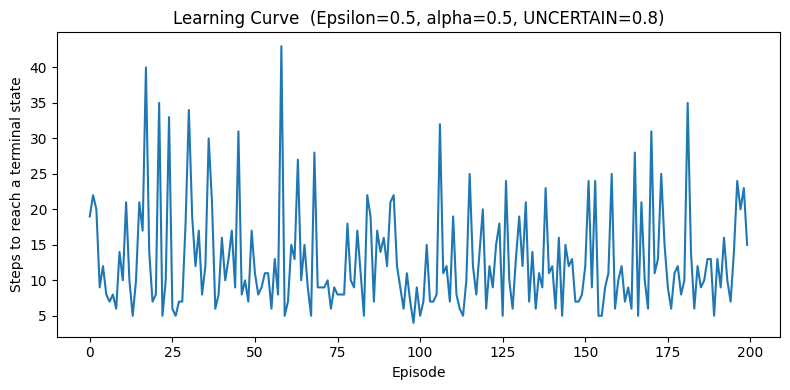

Learned policy after 200 episodes:
|   R    |   R    |   R    |   +1   |
|   U    |  WALL  |   U    |   -1   |
|   U    |   R    |   U    |   L    |



In [10]:
import matplotlib.pyplot as plt

# Reset the environment before this new training run
U = [[0,0,0,1], [0,0,0,-1], [0,0,0,0]]
Q = {(0,0):[0,0,0,0], (0,1):[0,0,0,0], (0,2):[0,0,0,0], (1,0):[0,0,0,0], (1,2):[0,0,0,0],
     (2,0):[0,0,0,0], (2,1):[0,0,0,0], (2,2):[0,0,0,0], (2,3):[0,0,0,0]}

EPISODES = 200
steps_per_episode = []

for ep in range(EPISODES):
    r, c = 2, 0
    steps = 0
    while True:
        selAct, action = SelectAction(Q[(r,c)], r, c)
        r, c, Q = computeQ(r, c, selAct, action)
        steps += 1
        if r <= 1 and c == 3:
            break
    steps_per_episode.append(steps)

plt.figure(figsize=(8,4))
plt.plot(steps_per_episode)
plt.xlabel("Episode")
plt.ylabel("Steps to reach a terminal state")
plt.title(f"Learning Curve  (Epsilon={Epsilon}, alpha={alpha}, UNCERTAIN={UNCERTAIN})")
plt.tight_layout()
plt.show()

print("Learned policy after", EPISODES, "episodes:")
printEnvironment(Q, policy=True)

### **Task2: Take the Screenshot**

### Step 9 (continued): Why the Policy Isn't Optimal Yet
<font size="4">Even after 200 episodes, the learned policy above may not match the true optimal policy. There are two independent, well-known reasons a Q-learning run can converge to something suboptimal, and the two cells below let you see evidence for each one directly instead of just guessing:</font>

<font size="4">
1. __Not enough episodes / uneven state coverage.__ The agent always starts at $(2,0)$, so states near the optimal path get visited constantly while states off the path (corners, cells behind the wall) may only be visited a handful of times in 200 episodes. A Q-value based on 3 samples is far less trustworthy than one based on 300. The cell below counts how many times each state was actually visited during training.<br><br>
2. __A constant (non-decaying) learning rate $\alpha$.__ Formal Q-learning convergence proofs require $\alpha$ to shrink over time. With a __fixed__ $\alpha=0.5$, every new sample — even late in training — still overwrites 50% of the current estimate. Since the environment is stochastic (`UNCERTAIN=0.8`), this means Q-values never fully settle; they keep jittering around the true value indefinitely, which can occasionally flip which action looks "best" between runs. The second cell below compares a fixed $\alpha$ against a __decaying__ $\alpha$ side by side.</font>

In [11]:
# --- Diagnostic 1: How many times was each state actually visited? ---
U = [[0,0,0,1], [0,0,0,-1], [0,0,0,0]]
Q = {(0,0):[0,0,0,0], (0,1):[0,0,0,0], (0,2):[0,0,0,0], (1,0):[0,0,0,0], (1,2):[0,0,0,0],
     (2,0):[0,0,0,0], (2,1):[0,0,0,0], (2,2):[0,0,0,0], (2,3):[0,0,0,0]}

visit_counts = {s: 0 for s in Q.keys()}

for ep in range(EPISODES):
    r, c = 2, 0
    while True:
        visit_counts[(r, c)] += 1
        selAct, action = SelectAction(Q[(r,c)], r, c)
        r, c, Q = computeQ(r, c, selAct, action)
        if r <= 1 and c == 3:
            break

print(f"State visit counts over {EPISODES} episodes:")
for r in range(NUM_ROW):
    row_str = "  "
    for c in range(NUM_COL):
        if (r, c) in visit_counts:
            row_str += f"{(r,c)}: {visit_counts[(r,c)]:>5} | "
        else:
            row_str += " " * 14 + "| "
    print(row_str)

least_visited = min(visit_counts, key=visit_counts.get)
most_visited = max(visit_counts, key=visit_counts.get)
print(f"\nMost visited state:  {most_visited} ({visit_counts[most_visited]} visits)")
print(f"Least visited state: {least_visited} ({visit_counts[least_visited]} visits)")
print("A state with very few visits has an unreliable Q-value estimate, regardless of alpha.")

State visit counts over 200 episodes:
  (0, 0):   258 | (0, 1):   293 | (0, 2):   314 |               | 
  (1, 0):   258 |               | (1, 2):   192 |               | 
  (2, 0):   424 | (2, 1):   342 | (2, 2):   232 | (2, 3):    34 | 

Most visited state:  (2, 0) (424 visits)
Least visited state: (2, 3) (34 visits)
A state with very few visits has an unreliable Q-value estimate, regardless of alpha.


#### Fixed vs. Decaying Learning Rate
<font size="4">Now retrain twice with everything else identical — once with a fixed $\alpha$, once with $\alpha$ decaying over episodes — and compare (a) how the Q-value for one representative state oscillates over training, and (b) how many times the greedy policy still changes in the final 50 episodes of each run. If the fixed-$\alpha$ run keeps changing its "best" action late in training while the decaying-$\alpha$ run settles down, that confirms $\alpha$ (not exploration) is the main source of the suboptimal / unstable policy.</font>

Policy flips in the final 50 episodes (fixed alpha=0.5):    7
Policy flips in the final 50 episodes (decaying alpha):     0


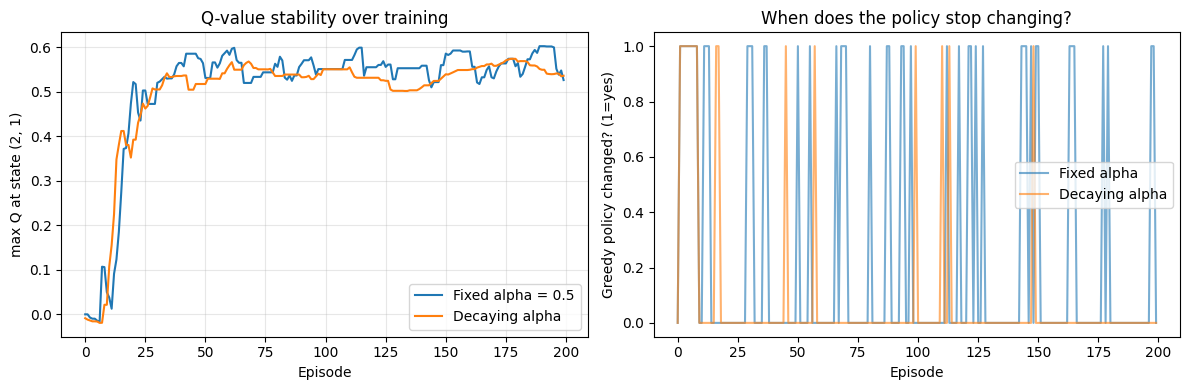

In [12]:
# --- Diagnostic 2: Fixed alpha vs. decaying alpha ---
import matplotlib.pyplot as plt

TRACK_STATE = (2, 1)  # a representative non-trivial state to watch

def train_and_track(episodes, alpha0, decay):
    global U, Q, alpha
    U = [[0,0,0,1], [0,0,0,-1], [0,0,0,0]]
    Q = {(0,0):[0,0,0,0], (0,1):[0,0,0,0], (0,2):[0,0,0,0], (1,0):[0,0,0,0], (1,2):[0,0,0,0],
         (2,0):[0,0,0,0], (2,1):[0,0,0,0], (2,2):[0,0,0,0], (2,3):[0,0,0,0]}

    qvalue_trace = []
    policy_history = []

    for ep in range(episodes):
        alpha = alpha0 / (1 + 0.02 * ep) if decay else alpha0

        r, c = 2, 0
        while True:
            selAct, action = SelectAction(Q[(r,c)], r, c)
            r, c, Q = computeQ(r, c, selAct, action)
            if r <= 1 and c == 3:
                break

        qvalue_trace.append(max(Q[TRACK_STATE]))
        greedy_policy = tuple(max(range(NUM_ACTIONS), key=lambda a: Q[s][a]) for s in sorted(Q.keys()))
        policy_history.append(greedy_policy)

    return qvalue_trace, policy_history

def count_policy_flips(policy_history, last_n=50):
    recent = policy_history[-last_n:]
    return sum(1 for i in range(1, len(recent)) if recent[i] != recent[i-1])

qtrace_fixed, policy_fixed = train_and_track(EPISODES, alpha0=0.5, decay=False)
qtrace_decay, policy_decay = train_and_track(EPISODES, alpha0=0.5, decay=True)

print(f"Policy flips in the final 50 episodes (fixed alpha=0.5):    {count_policy_flips(policy_fixed)}")
print(f"Policy flips in the final 50 episodes (decaying alpha):     {count_policy_flips(policy_decay)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(qtrace_fixed, label="Fixed alpha = 0.5")
axes[0].plot(qtrace_decay, label="Decaying alpha")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel(f"max Q at state {TRACK_STATE}")
axes[0].set_title("Q-value stability over training")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([1 if i>0 and policy_fixed[i]!=policy_fixed[i-1] else 0 for i in range(len(policy_fixed))],
             label="Fixed alpha", alpha=0.6)
axes[1].plot([1 if i>0 and policy_decay[i]!=policy_decay[i-1] else 0 for i in range(len(policy_decay))],
             label="Decaying alpha", alpha=0.6)
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Greedy policy changed? (1=yes)")
axes[1].set_title("When does the policy stop changing?")
axes[1].legend()

plt.tight_layout()
plt.show()

### **Task3: Take the Screenshot**

#### Is the Decaying-Alpha Policy Actually Optimal?
<font size="4">Rather than eyeballing it, we can check directly: since we __know__ the exact transition model (80% intended / 10% each perpendicular) and reward structure, we can compute the __true optimal policy__ with classical __Value Iteration__ (a model-based dynamic-programming method, not Q-learning). This gives ground truth to compare both learned policies against.</font>

In [13]:
# --- Ground-truth optimal policy via Value Iteration (uses the known transition model directly) ---
TERMINALS = {(0, 3): 1.0, (1, 3): -1.0}

def next_state(r, c, a):
    dr, dc = ACTIONS[a]
    nr, nc = r + dr, c + dc
    if nr < 0 or nc < 0 or nr >= NUM_ROW or nc >= NUM_COL or (nr == nc == 1):
        return r, c
    return nr, nc

def action_value(V, r, c, a):
    probs = {a: UNCERTAIN, (a-1) % NUM_ACTIONS: (1-UNCERTAIN)/2, (a+1) % NUM_ACTIONS: (1-UNCERTAIN)/2}
    val = 0.0
    for act, p in probs.items():
        nr, nc = next_state(r, c, act)
        nextV = TERMINALS.get((nr, nc), V.get((nr, nc), 0.0))
        val += p * (REWARD + DISCOUNT * nextV)
    return val

def value_iteration(theta=1e-8):
    V = {s: 0.0 for s in Q.keys()}
    while True:
        delta = 0
        newV = {}
        for (r, c) in V:
            newV[(r, c)] = max(action_value(V, r, c, a) for a in range(NUM_ACTIONS))
            delta = max(delta, abs(newV[(r, c)] - V[(r, c)]))
        V = newV
        if delta < theta:
            break
    policy = {}
    for (r, c) in V:
        policy[(r, c)] = max(range(NUM_ACTIONS), key=lambda a: action_value(V, r, c, a))
    return V, policy

V_star, optimal_policy = value_iteration()

ACTION_LABELS = ["D", "L", "U", "R"]
print("Ground-truth OPTIMAL policy (Value Iteration):")
for r in range(NUM_ROW):
    row = "  "
    for c in range(NUM_COL):
        if r == c == 1:
            row += " WALL |"
        elif (r, c) in TERMINALS:
            row += ("  +1  |" if r == 0 else "  -1  |")
        else:
            row += f"   {ACTION_LABELS[optimal_policy[(r,c)]]}   |"
    print(row)

# --- Compare against the Q-learning policies from the previous cell ---
sorted_states = sorted(Q.keys())
optimal_tuple = tuple(optimal_policy[s] for s in sorted_states)

def match_count(learned_tuple):
    return sum(1 for a, b in zip(learned_tuple, optimal_tuple) if a == b), len(optimal_tuple)

m_fixed, total = match_count(policy_fixed[-1])
m_decay, _ = match_count(policy_decay[-1])

print(f"\nFixed-alpha final policy matches optimal in   {m_fixed}/{total} states")
print(f"Decaying-alpha final policy matches optimal in {m_decay}/{total} states")

mismatches_fixed = [s for s, a, b in zip(sorted_states, policy_fixed[-1], optimal_tuple) if a != b]
mismatches_decay = [s for s, a, b in zip(sorted_states, policy_decay[-1], optimal_tuple) if a != b]
print(f"\nStates where fixed-alpha disagrees with optimal:   {mismatches_fixed}")
print(f"States where decaying-alpha disagrees with optimal: {mismatches_decay}")

Ground-truth OPTIMAL policy (Value Iteration):
     R   |   R   |   R   |  +1  |
     U   | WALL |   U   |  -1  |
     U   |   R   |   U   |   L   |

Fixed-alpha final policy matches optimal in   8/9 states
Decaying-alpha final policy matches optimal in 8/9 states

States where fixed-alpha disagrees with optimal:   [(2, 0)]
States where decaying-alpha disagrees with optimal: [(2, 0)]


#### Does More Training Fix It?
<font size="4">The mismatches above were concentrated in the __least-visited__ states — evidence that 200 episodes just isn't enough coverage, regardless of the $\alpha$ schedule. The cell below reruns training with __decaying $\alpha$__ but many more episodes, and re-checks the match rate against the ground-truth optimal policy from Value Iteration. If coverage was really the bottleneck, the match rate should climb toward 9/9 as episodes increase.</font>

In [14]:
# --- Does increasing episodes (with decaying alpha) close the gap? ---
for EPISODES_TEST in [200, 1000, 5000]:
    qtrace_long, policy_long = train_and_track(EPISODES_TEST, alpha0=0.5, decay=True)
    m_long, total = match_count(policy_long[-1])
    mismatches_long = [s for s, a, b in zip(sorted_states, policy_long[-1], optimal_tuple) if a != b]
    print(f"Episodes={EPISODES_TEST:>5}  ->  matches optimal in {m_long}/{total} states"
          f"   | mismatches: {mismatches_long}")

Episodes=  200  ->  matches optimal in 7/9 states   | mismatches: [(2, 1), (2, 2)]
Episodes= 1000  ->  matches optimal in 8/9 states   | mismatches: [(2, 0)]
Episodes= 5000  ->  matches optimal in 8/9 states   | mismatches: [(2, 0)]


#### Why Does $(2,1)$ Stay Wrong Even at 5000 Episodes?
<font size="4">If a state keeps resisting convergence no matter how much training you throw at it, the next question is: __is it a genuine near-tie in Q\*-values__ (in which case slow/uncertain convergence is expected and not a bug), or is something else going on? We can check directly using the exact Q\*-values from Value Iteration at $(2,1)$.</font>

In [15]:
# --- Inspect the true Q*-value gap at the stubborn state (2,1) ---
r, c = 2, 1
true_qvals = [action_value(V_star, r, c, a) for a in range(NUM_ACTIONS)]
for label, v in zip(["Down", "Left", "Up", "Right"], true_qvals):
    print(f"Q*({r},{c}, {label}) = {v:.6f}")

sorted_vals = sorted(true_qvals, reverse=True)
gap = sorted_vals[0] - sorted_vals[1]
print(f"\nGap between best and 2nd-best action: {gap:.6f}")

# For comparison, what's the gap at a state that DID converge correctly, e.g. (0,0)?
r2, c2 = 0, 0
true_qvals2 = [action_value(V_star, r2, c2, a) for a in range(NUM_ACTIONS)]
sorted_vals2 = sorted(true_qvals2, reverse=True)
gap2 = sorted_vals2[0] - sorted_vals2[1]
print(f"For comparison, gap at state {(r2,c2)} (which DID converge): {gap2:.6f}")

Q*(2,1, Down) = 0.339936
Q*(2,1, Left) = 0.375175
Q*(2,1, Up) = 0.339936
Q*(2,1, Right) = 0.375674

Gap between best and 2nd-best action: 0.000499
For comparison, gap at state (0, 0) (which DID converge): 0.061244


### **Learning Rate**
<font size="4">Let's explore the critical roles of the learning rate in Q-learning. </font>

### Use the code below to answer the follwoing questions

### **CODE for Task 3**

<font size="4">__ACTION REQUIRED:__ Before proceeding, you must execute the code cells containing the definitions for $printEnvironment$, $SelectAction$, $updateU$, and $computeQ$.</font>

In [16]:
import random
import copy

# Arguments
Epsilon = 0.2
alpha = 0.5
REWARD = -0.01 # constant reward for non-terminal states
DISCOUNT = 0.9
UNCERTAIN = 0.9
Iter = 10

def Qlearning():
    #U is maxQ except terminal states
    U = [[0, 0, 0, 1], [0, 0, 0, -1], [0, 0, 0, 0]]
    # Q values in the list in the order of Down, Left, Up, Right
    Q = {(0,0):[0,0,0,0], (0,1):[0,0,0,0], (0,2):[0,0,0,0], (1,0):[0,0,0,0], (1,2):[0,0,0,0],
        (2,0):[0,0,0,0], (2,1):[0,0,0,0], (2,2):[0,0,0,0], (2,3):[0,0,0,0]}

    MAX_ERROR = 10**(-4)
    count = 0

    while True:
        preQ = copy.deepcopy(Q)
        #set start state
        r, c = 2, 0
        count = count + 1
        while True:
            selAct, action = SelectAction(Q[(r,c)], r, c)
            r, c, Q = computeQ(r,c,selAct, action)

            if r <= 1 and c == 3:
                break

        if count > 50:
            error = 0
            for keys in Q:
                for i in range(NUM_ACTIONS):
                    error = max(error, abs(Q[keys][i]-preQ[keys][i]))

            if error < MAX_ERROR :
                break;

        #preQ = copy.deepcopy(Q)
    return count

cnt_sum = 0
for i in range(Iter):
    cnt = Qlearning()
    print("At i=", i+1, " Number of iterations:", cnt)
    cnt_sum += cnt
print("-"*30)
print("The learning rage:", alpha)
print("The AVERAGE number of iteration:", cnt_sum/Iter)

At i= 1  Number of iterations: 18166
At i= 2  Number of iterations: 18896
At i= 3  Number of iterations: 3783
At i= 4  Number of iterations: 4376
At i= 5  Number of iterations: 2662
At i= 6  Number of iterations: 31684
At i= 7  Number of iterations: 10169
At i= 8  Number of iterations: 15313
At i= 9  Number of iterations: 6666
At i= 10  Number of iterations: 9126
------------------------------
The learning rage: 0.5
The AVERAGE number of iteration: 12084.1


### **Task4**
<font size="4">Test the Q-learning algorithm with $\alpha = 0.5$, $\alpha = 0.6$, $\alpha = 0.7$, and $\alpha = 0.8$. Fix all other hyperparameters for consistent comparison.<br></font>

<font size="4">Use the plot to compare the average number of iterations with above learning rates. Place a __Screenshot__ of the plot in the report.</font>